# 🏎️ Nina's F1 Predictions: 2026 Japanese Grand Prix (Round 3)
## Suzuka Circuit — March 27-29, 2026

**Model version:** v0.5 (Two-model + weather + speed traps + tire strategy + pit data)  
**Data:** 72 races, 1,442 results + weather + lap-level telemetry for 10 key races  
**Last updated:** March 24, 2026

### What's New in v0.5
- **Speed trap data:** Straight-line speed per team — critical for Suzuka's 1.2km back straight
- **Tire strategy:** Pit stop count, stint length, compound preferences
- **Lap consistency:** How much variation each driver has lap-to-lap (lower = more reliable)
- **Pit crew speed:** Which teams execute faster stops (constructor fantasy scoring)
- Everything from v0.4: two-model approach, weather, rain scenarios


In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from collections import defaultdict
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

# Load all data
df = pd.read_csv('../data/all_results.csv')
weather = pd.read_csv('../data/weather.csv')
lap_stats = pd.read_csv('../data/lap_stats.csv')

df['Position'] = pd.to_numeric(df['Position'], errors='coerce')
df['GridPosition'] = pd.to_numeric(df['GridPosition'], errors='coerce')
df['DNF'] = df['Status'].apply(lambda x: 0 if x == 'Finished' or (isinstance(x, str) and 'Lap' in x) else 1)
df = df.sort_values(['Year', 'Round']).reset_index(drop=True)
df = df.merge(weather[['Year','Round','avg_air_temp','avg_track_temp','avg_humidity','avg_wind_speed','had_rain','rain_pct']], on=['Year','Round'], how='left')

print(f"Race results: {len(df)} entries, {df[['Year','Round']].drop_duplicates().shape[0]} races")
print(f"Weather: {len(weather)} races ({weather['had_rain'].sum()} wet)")
print(f"Lap telemetry: {len(lap_stats)} driver-race entries across {lap_stats[['Year','Round']].drop_duplicates().shape[0]} races")


Race results: 1442 entries, 72 races
Weather: 72 races (16 wet)
Lap telemetry: 203 driver-race entries across 10 races


## 1. Speed & Telemetry Analysis

New data reveals which teams have the fastest cars on straights — crucial at Suzuka with its 1.2km back straight where DRS overtakes happen.


  ⚡ 2026 TEAM TELEMETRY PROFILES

  Team                    Trap Speed   Top Speed   Avg Pits    Lap ±
  --------------------------------------------------------------
  Mercedes                     298       326       1.0  ± 0.89s
  Red Bull Racing              298       325       1.5  ± 0.72s
  Ferrari                      296       322       1.0  ± 0.84s
  Alpine                       295       326       1.2  ± 0.96s
  Audi                         295       325       0.8  ± 1.03s
  Racing Bulls                 292       320       1.2  ± 1.30s
  Haas F1 Team                 291       320       1.2  ± 1.10s
  Williams                     290       315       1.5  ± 1.23s
  Cadillac                     285       315       1.2  ± 1.28s
  Aston Martin                 282       309       2.2  ± 0.85s
  McLaren                      279       297       0.7  ± 1.09s


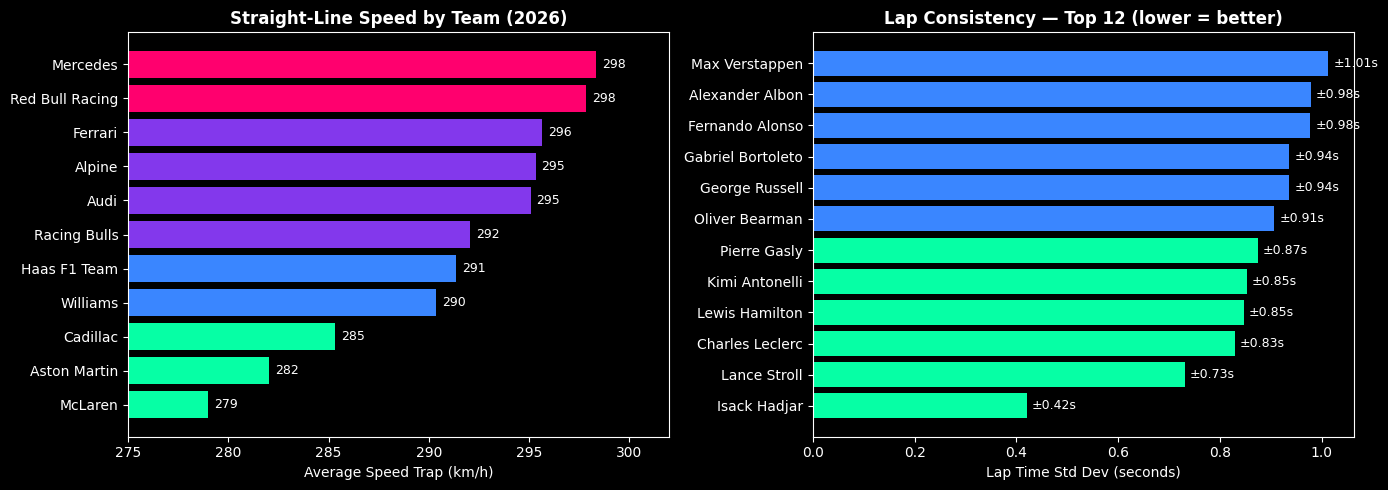

In [2]:
# 2026 team speed profiles
speeds_2026 = lap_stats[lap_stats['Year'] == 2026].groupby('Team').agg(
    avg_trap_speed=('avg_speed_st', 'mean'),
    top_speed=('top_speed', 'mean'),
    avg_pits=('n_pits', 'mean'),
    lap_consistency=('lap_time_std', 'mean')
).sort_values('avg_trap_speed', ascending=False).reset_index()

print("=" * 75)
print("  ⚡ 2026 TEAM TELEMETRY PROFILES")
print("=" * 75)
print(f"\n  {'Team':22s}  {'Trap Speed':>10s}  {'Top Speed':>10s}  {'Avg Pits':>9s}  {'Lap ±':>7s}")
print("  " + "-" * 62)
for _, row in speeds_2026.iterrows():
    print(f"  {row['Team']:22s}  {row['avg_trap_speed']:>8.0f}  {row['top_speed']:>8.0f}  {row['avg_pits']:>8.1f}  ±{row['lap_consistency']:>5.2f}s")

# Speed advantage chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Speed trap chart
teams_sorted = speeds_2026.sort_values('avg_trap_speed')
colors = ['#ff006e' if s > 296 else '#8338ec' if s > 292 else '#3a86ff' if s > 288 else '#06ffa5' for s in teams_sorted['avg_trap_speed']]
ax1.barh(teams_sorted['Team'], teams_sorted['avg_trap_speed'], color=colors)
ax1.set_xlabel('Average Speed Trap (km/h)')
ax1.set_title('Straight-Line Speed by Team (2026)', fontweight='bold')
ax1.set_xlim(275, 302)
for i, (_, row) in enumerate(teams_sorted.iterrows()):
    ax1.text(row['avg_trap_speed']+0.3, i, f"{row['avg_trap_speed']:.0f}", va='center', fontsize=9)

# Consistency chart
drivers_2026 = lap_stats[lap_stats['Year'] == 2026].groupby('FullName')['lap_time_std'].mean().sort_values().head(12)
colors2 = ['#06ffa5' if s < 0.9 else '#3a86ff' if s < 1.1 else '#8338ec' for s in drivers_2026.values]
ax2.barh(drivers_2026.index, drivers_2026.values, color=colors2)
ax2.set_xlabel('Lap Time Std Dev (seconds)')
ax2.set_title('Lap Consistency — Top 12 (lower = better)', fontweight='bold')
for i, (driver, val) in enumerate(drivers_2026.items()):
    ax2.text(val+0.01, i, f'±{val:.2f}s', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/telemetry_v5.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. Suzuka-Specific Analysis

Suzuka is a **power-sensitive track** with a 1.2km back straight. Teams with higher trap speeds have a significant overtaking advantage. Let's compare team speeds specifically at Suzuka.


In [3]:
# Suzuka speed data (2023-2025)
suzuka_speeds = lap_stats[lap_stats['Label'].str.contains('Japan')].groupby('Team').agg(
    suzuka_trap=('avg_speed_st', 'mean'),
    suzuka_top=('top_speed', 'mean'),
    suzuka_consistency=('lap_time_std', 'mean')
).sort_values('suzuka_trap', ascending=False)

# Merge 2026 speeds with Suzuka historical
print("=" * 70)
print("  🗾 SUZUKA SPEED PROFILES")
print("=" * 70)
print(f"\n  {'Team':22s}  {'2026 Trap':>10s}  {'Suzuka Hist':>12s}  {'Gap':>6s}")
print("  " + "-" * 55)

for _, row in speeds_2026.iterrows():
    team = row['Team']
    s2026 = row['avg_trap_speed']
    s_hist = suzuka_speeds.loc[team]['suzuka_trap'] if team in suzuka_speeds.index else np.nan
    gap = s2026 - s_hist if not np.isnan(s_hist) else 0
    hist_str = f"{s_hist:.0f}" if not np.isnan(s_hist) else "  new"
    gap_str = f"+{gap:.0f}" if gap > 0 else f"{gap:.0f}" if gap < 0 else ""
    print(f"  {team:22s}  {s2026:>8.0f}  {hist_str:>12s}  {gap_str:>6s}")

print("\n  Key insight: Suzuka's back straight rewards top speed.")
print("  Mercedes + Red Bull have the best trap speeds in 2026.")
print("  McLaren's 279 km/h trap speed will make overtaking very difficult.")


  🗾 SUZUKA SPEED PROFILES

  Team                     2026 Trap   Suzuka Hist     Gap
  -------------------------------------------------------
  Mercedes                     298           293      +6
  Red Bull Racing              298           282     +15
  Ferrari                      296           293      +3
  Alpine                       295           293      +3
  Audi                         295           new        
  Racing Bulls                 292           300      -8
  Haas F1 Team                 291           293      -1
  Williams                     290           285      +5
  Cadillac                     285           new        
  Aston Martin                 282           288      -6
  McLaren                      279           293     -14

  Key insight: Suzuka's back straight rewards top speed.
  Mercedes + Red Bull have the best trap speeds in 2026.
  McLaren's 279 km/h trap speed will make overtaking very difficult.


## 3. Model A — Car Pace (2026 Only + Speed Data)


In [4]:
data_2026 = df[df['Year'] == 2026].copy()
constructor_pace = data_2026.groupby('TeamName').agg(
    avg_finish=('Position', 'mean'),
    avg_grid=('GridPosition', 'mean'),
    best_finish=('Position', 'min'),
).reset_index().sort_values('avg_finish')

# Add speed trap data
constructor_pace = constructor_pace.merge(
    speeds_2026[['Team', 'avg_trap_speed', 'top_speed', 'lap_consistency']].rename(columns={'Team': 'TeamName'}),
    on='TeamName', how='left'
)

def tier(avg):
    if avg <= 3: return 'Tier 1'
    elif avg <= 7: return 'Tier 2'
    elif avg <= 12: return 'Tier 3'
    elif avg <= 16: return 'Tier 4'
    else: return 'Tier 5'

constructor_pace['Tier'] = constructor_pace['avg_finish'].apply(tier)
car_pace = dict(zip(constructor_pace['TeamName'], constructor_pace['avg_finish']))
car_speed = dict(zip(constructor_pace['TeamName'], constructor_pace['avg_trap_speed'].fillna(290)))

print("=" * 80)
print("  🏗️ CAR PACE + SPEED — 2026 Only")
print("=" * 80)
print(f"\n  {'Team':22s}  {'Avg Fin':>8s}  {'Trap Spd':>9s}  {'Top Spd':>8s}  {'Tier'}")
print("  " + "-" * 60)
for _, row in constructor_pace.iterrows():
    print(f"  {row['TeamName']:22s}  P{row['avg_finish']:>6.1f}  {row['avg_trap_speed']:>7.0f}  {row['top_speed']:>6.0f}  {row['Tier']}")


  🏗️ CAR PACE + SPEED — 2026 Only

  Team                     Avg Fin   Trap Spd   Top Spd  Tier
  ------------------------------------------------------------
  Mercedes                P   1.5      298     326  Tier 1
  Ferrari                 P   3.5      296     322  Tier 2
  Haas F1 Team            P   9.2      291     320  Tier 3
  Alpine                  P  10.0      295     326  Tier 3
  Racing Bulls            P  10.0      292     320  Tier 3
  Red Bull Racing         P  12.5      298     325  Tier 4
  Williams                P  14.5      290     315  Tier 4
  Audi                    P  15.8      295     325  Tier 4
  Cadillac                P  15.8      285     315  Tier 4
  McLaren                 P  16.2      279     297  Tier 5
  Aston Martin            P  17.5      282     309  Tier 5


## 4. Model B — Driver Skill (Car-Independent + Consistency)


In [5]:
df['race_id'] = df['Year'].astype(str) + '_' + df['Round'].astype(str)
race_order = df[['race_id','Year','Round']].drop_duplicates().sort_values(['Year','Round']).reset_index(drop=True)
race_order['race_seq'] = range(len(race_order))
df = df.merge(race_order[['race_id','race_seq']], on='race_id', how='left')

# Build driver consistency from lap stats
driver_consistency = lap_stats.groupby('FullName')['lap_time_std'].mean().to_dict()

features_list = []
for race_seq in sorted(df['race_seq'].unique()):
    race_data = df[df['race_seq'] == race_seq].copy()
    for _, row in race_data.iterrows():
        driver = row['FullName']
        team = row['TeamName']
        race_name = row['RaceName']
        hist = df[(df['FullName'] == driver) & (df['race_seq'] < race_seq)]
        hist_team = df[(df['TeamName'] == team) & (df['race_seq'] < race_seq)]
        last5 = hist.tail(5)
        last5_team = hist_team.tail(5)
        last10 = hist.tail(10)
        
        tm_hist = df[(df['TeamName'] == team) & (df['FullName'] != driver) & (df['race_seq'] < race_seq)]
        tm_d = []
        for seq in hist.tail(5)['race_seq'].values:
            my = hist[hist['race_seq'] == seq]['Position'].values
            tm = tm_hist[tm_hist['race_seq'] == seq]['Position'].values
            if len(my) > 0 and len(tm) > 0 and not np.isnan(my[0]) and not np.isnan(tm[0]):
                tm_d.append(tm[0] - my[0])
        
        wet_hist = hist[hist['had_rain'] == True]
        wet_gain = (wet_hist['GridPosition'] - wet_hist['Position']).mean() if len(wet_hist) > 0 else 0
        track_hist = hist[hist['RaceName'] == race_name]
        
        features_list.append({
            'race_seq': race_seq, 'Year': row['Year'], 'Round': row['Round'],
            'RaceName': race_name, 'FullName': driver, 'TeamName': team,
            'grid_position': row['GridPosition'], 'finish_position': row['Position'],
            'car_pace': car_pace.get(team, 15) if row['Year'] == 2026 else last5_team['Position'].mean() if len(last5_team) > 0 else 12,
            'car_speed': car_speed.get(team, 290) if row['Year'] == 2026 else 290,
            'driver_avg_finish': last5['Position'].mean() if len(last5) > 0 else 12,
            'positions_gained_avg': (last5['GridPosition'] - last5['Position']).mean() if len(last5) > 0 else 0,
            'teammate_delta': np.mean(tm_d) if len(tm_d) > 0 else 0,
            'dnf_rate': last10['DNF'].mean() if len(last10) > 0 else 0.1,
            'consistency': driver_consistency.get(driver, 1.5),
            'track_experience': len(track_hist),
            'wet_skill': wet_gain,
            'air_temp': row.get('avg_air_temp', 22),
            'track_temp': row.get('avg_track_temp', 35),
            'humidity': row.get('avg_humidity', 50),
            'had_rain': 1 if row.get('had_rain', False) else 0,
            'is_2026': 1 if row['Year'] == 2026 else 0,
            'DNF': row['DNF']
        })

feat_df = pd.DataFrame(features_list).dropna(subset=['finish_position', 'grid_position'])

# Show driver skill rankings
grid_2026 = data_2026['FullName'].unique()
skills = []
for d in grid_2026:
    dh = feat_df[feat_df['FullName'] == d].sort_values('race_seq')
    if len(dh) > 0:
        l = dh.iloc[-1]
        skills.append({'Driver': d, 'Team': l['TeamName'],
            'TM_Delta': l['teammate_delta'], 'Pos_Gained': l['positions_gained_avg'],
            'Consistency': l['consistency'], 'Wet': l['wet_skill']})

skill_df = pd.DataFrame(skills).sort_values('TM_Delta', ascending=False)

print("=" * 80)
print("  👤 DRIVER SKILL + CONSISTENCY + WET WEATHER")
print("=" * 80)
print(f"\n  {'Driver':22s}  {'Team':18s}  {'vs TM':>6s}  {'Gained':>7s}  {'Consist':>8s}  {'Wet':>5s}")
print("  " + "-" * 72)
for _, r in skill_df.iterrows():
    tm = f"+{r['TM_Delta']:.1f}" if r['TM_Delta'] > 0 else f"{r['TM_Delta']:.1f}"
    pg = f"+{r['Pos_Gained']:.1f}" if r['Pos_Gained'] > 0 else f"{r['Pos_Gained']:.1f}"
    wet = f"+{r['Wet']:.1f}" if r['Wet'] > 0 else f"{r['Wet']:.1f}"
    print(f"  {r['Driver']:22s}  {r['Team']:18s}  {tm:>6s}  {pg:>7s}  ±{r['Consistency']:>6.2f}s  {wet:>5s}")


  👤 DRIVER SKILL + CONSISTENCY + WET WEATHER

  Driver                  Team                 vs TM   Gained   Consist    Wet
  ------------------------------------------------------------------------
  Gabriel Bortoleto       Audi                 +13.0     +0.4  ±  0.98s   -1.5
  Max Verstappen          Red Bull Racing      +12.2     +6.6  ±  1.03s   +0.9
  Arvid Lindblad          Racing Bulls          +5.0     +1.0  ±  1.51s    0.0
  Fernando Alonso         Aston Martin          +4.4     -1.4  ±  0.98s   +0.1
  Lando Norris            McLaren               +3.6     -4.0  ±  0.94s   -1.9
  Carlos Sainz            Williams              +3.4     +1.8  ±  1.15s   -1.1
  Sergio Perez            Cadillac              +3.0     -2.0  ±  1.14s   +3.0
  Charles Leclerc         Ferrari               +2.4     -1.4  ±  0.98s   -3.1
  Pierre Gasly            Alpine                +2.0     -1.4  ±  1.53s   +3.0
  George Russell          Mercedes              +1.8     +0.2  ±  0.99s   -2.1
  Esteban 

## 5. XGBoost v0.5 — Now With Speed + Consistency


  🤖 XGBOOST v0.5 PERFORMANCE

  Validation MAE: 2.50 positions
  Residual StdDev: 2.51
  Features: 15 (added car_speed, consistency)


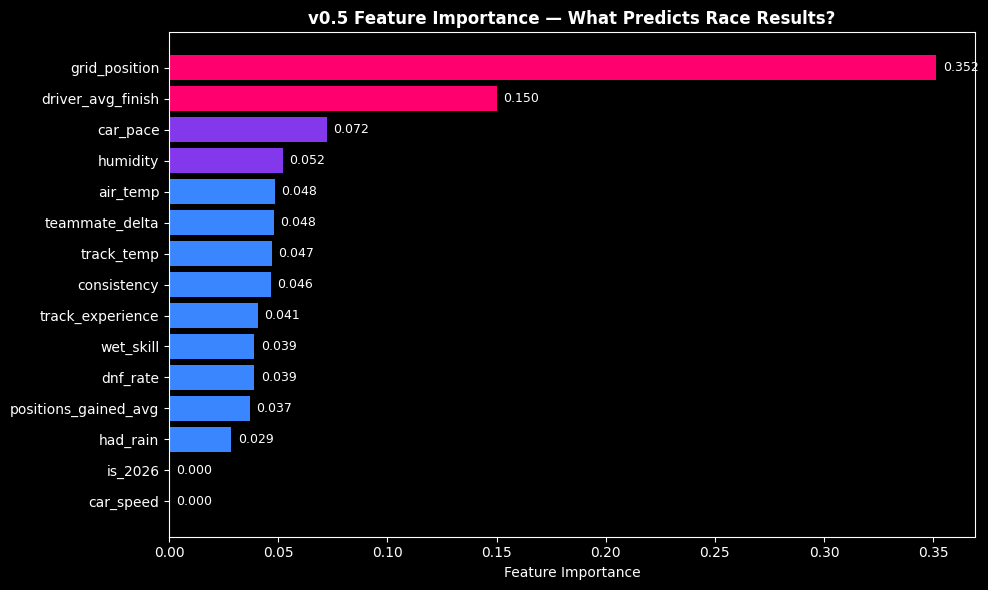

In [6]:
feature_cols = ['grid_position', 'car_pace', 'car_speed', 'driver_avg_finish',
                'positions_gained_avg', 'teammate_delta', 'dnf_rate',
                'consistency', 'track_experience', 'wet_skill',
                'air_temp', 'track_temp', 'humidity', 'had_rain', 'is_2026']

train = feat_df[(feat_df['Year'] < 2026) & (feat_df['DNF'] == 0)].copy()
val = feat_df[(feat_df['Year'] == 2026) & (feat_df['DNF'] == 0)].copy()

X_train = train[feature_cols].fillna(0)
y_train = train['finish_position']
X_val = val[feature_cols].fillna(0)
y_val = val['finish_position']

model = XGBRegressor(
    n_estimators=250, max_depth=6, learning_rate=0.08,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
)
model.fit(X_train, y_train)

val_pred = model.predict(X_val)
val_mae = mean_absolute_error(y_val, val_pred)
residual_std = np.std(y_val.values - val_pred)

print("=" * 60)
print("  🤖 XGBOOST v0.5 PERFORMANCE")
print("=" * 60)
print(f"\n  Validation MAE: {val_mae:.2f} positions")
print(f"  Residual StdDev: {residual_std:.2f}")
print(f"  Features: {len(feature_cols)} (added car_speed, consistency)")

# Feature importance
importance = pd.DataFrame({
    'Feature': feature_cols, 'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#ff006e' if v > 0.1 else '#8338ec' if v > 0.05 else '#3a86ff' if v > 0.02 else '#06ffa5' for v in importance['Importance']]
ax.barh(importance['Feature'], importance['Importance'], color=colors)
ax.set_xlabel('Feature Importance')
ax.set_title('v0.5 Feature Importance — What Predicts Race Results?', fontweight='bold')
for i, (f, imp) in enumerate(zip(importance['Feature'], importance['Importance'])):
    ax.text(imp+0.003, i, f'{imp:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/importance_v5.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Japan GP Predictions (v0.5)

Now incorporating car speed data and lap consistency alongside the two-model approach.


In [7]:
japan_preds = []
for driver in grid_2026:
    dh = feat_df[feat_df['FullName'] == driver].sort_values('race_seq')
    if len(dh) == 0: continue
    l = dh.iloc[-1]
    team = l['TeamName']
    suzuka_exp = len(dh[dh['RaceName'].str.contains('Japan', case=False, na=False)])
    
    features = {
        'grid_position': l.get('grid_position', 12),
        'car_pace': car_pace.get(team, 15),
        'car_speed': car_speed.get(team, 290),
        'driver_avg_finish': l['driver_avg_finish'],
        'positions_gained_avg': l['positions_gained_avg'],
        'teammate_delta': l['teammate_delta'],
        'dnf_rate': l['dnf_rate'],
        'consistency': l['consistency'],
        'track_experience': suzuka_exp,
        'wet_skill': l['wet_skill'],
        'air_temp': 18.0, 'track_temp': 25.0, 'humidity': 60.0,
        'had_rain': 0, 'is_2026': 1
    }
    
    X = pd.DataFrame([features])[feature_cols].fillna(0)
    pred = model.predict(X)[0]
    japan_preds.append({
        'Driver': driver, 'Team': team,
        'Car': car_pace.get(team, 15), 'Speed': car_speed.get(team, 290),
        'Skill': l['teammate_delta'], 'Consist': l['consistency'],
        'Suzuka': suzuka_exp, 'Predicted': pred, 'Features': features
    })

japan_preds.sort(key=lambda x: x['Predicted'])
for i, p in enumerate(japan_preds): p['Rank'] = i + 1

print("=" * 90)
print("  🏁 PREDICTED FINISH — 2026 JAPANESE GP (v0.5: Speed + Consistency)")
print("=" * 90)
print(f"\n  {'Pos':>3s}  {'Driver':22s}  {'Team':18s}  {'Car':>5s}  {'Spd':>5s}  {'Skill':>6s}  {'±Lap':>6s}  {'Pred':>6s}")
print("  " + "-" * 78)
for p in japan_preds:
    sk = f"+{p['Skill']:.1f}" if p['Skill'] > 0 else f"{p['Skill']:.1f}"
    print(f"  P{p['Rank']:>2d}  {p['Driver']:22s}  {p['Team']:18s}  P{p['Car']:>3.1f}  {p['Speed']:>4.0f}  {sk:>6s}  ±{p['Consist']:>4.2f}  P{p['Predicted']:>4.1f}")


  🏁 PREDICTED FINISH — 2026 JAPANESE GP (v0.5: Speed + Consistency)

  Pos  Driver                  Team                  Car    Spd   Skill    ±Lap    Pred
  ------------------------------------------------------------------------------
  P 1  Kimi Antonelli          Mercedes            P1.5   298    -1.8  ±1.03  P 2.1
  P 2  George Russell          Mercedes            P1.5   298    +1.8  ±0.99  P 2.6
  P 3  Charles Leclerc         Ferrari             P3.5   296    +2.4  ±0.98  P 4.6
  P 4  Max Verstappen          Red Bull Racing     P12.5   298   +12.2  ±1.03  P 5.8
  P 5  Lando Norris            McLaren             P16.2   279    +3.6  ±0.94  P 7.3
  P 6  Lewis Hamilton          Ferrari             P3.5   296    -2.4  ±1.09  P 7.3
  P 7  Oscar Piastri           McLaren             P16.2   279    -3.6  ±1.06  P 8.0
  P 8  Nico Hulkenberg         Audi                P15.8   295   -13.0  ±1.06  P 9.4
  P 9  Pierre Gasly            Alpine              P10.0   295    +2.0  ±1.53  P 9.8
 

## 7. Rain Scenario — What If It's Wet?


In [8]:
rain_preds = []
for p in japan_preds:
    fw = p['Features'].copy()
    fw['had_rain'] = 1
    fw['humidity'] = 85.0
    X_wet = pd.DataFrame([fw])[feature_cols].fillna(0)
    wet = model.predict(X_wet)[0]
    rain_preds.append({
        'Driver': p['Driver'], 'Team': p['Team'],
        'Dry': p['Predicted'], 'Wet': wet,
        'Shift': p['Predicted'] - wet
    })

rain_df = pd.DataFrame(rain_preds).sort_values('Shift', ascending=False)
print("=" * 70)
print("  🌧️ RAIN SCENARIO — Who Gains, Who Loses?")
print("=" * 70)
print(f"\n  {'Driver':22s}  {'Team':18s}  {'Dry':>5s}  {'Wet':>5s}  {'Shift':>7s}")
print("  " + "-" * 60)
for _, r in rain_df.iterrows():
    sh = f"+{r['Shift']:.1f}" if r['Shift'] > 0 else f"{r['Shift']:.1f}"
    em = '🟢' if r['Shift'] > 0.5 else '🔴' if r['Shift'] < -0.5 else '⚪'
    print(f"  {em} {r['Driver']:22s}  {r['Team']:18s}  P{r['Dry']:>3.1f}  P{r['Wet']:>3.1f}  {sh:>7s}")


  🌧️ RAIN SCENARIO — Who Gains, Who Loses?

  Driver                  Team                  Dry    Wet    Shift
  ------------------------------------------------------------
  🟢 Valtteri Bottas         Cadillac            P15.5  P12.9     +2.6
  🟢 Sergio Perez            Cadillac            P14.7  P12.5     +2.2
  🟢 Fernando Alonso         Aston Martin        P14.0  P12.6     +1.5
  🟢 Lance Stroll            Aston Martin        P14.5  P13.5     +1.1
  🟢 Alexander Albon         Williams            P16.1  P15.0     +1.0
  🟢 Liam Lawson             Racing Bulls        P13.6  P12.6     +1.0
  🟢 Carlos Sainz            Williams            P13.3  P12.3     +1.0
  ⚪ Esteban Ocon            Haas F1 Team        P13.2  P12.8     +0.4
  ⚪ Arvid Lindblad          Racing Bulls        P11.8  P11.5     +0.3
  ⚪ Nico Hulkenberg         Audi                P9.4  P9.2     +0.3
  ⚪ Kimi Antonelli          Mercedes            P2.1  P2.2     -0.1
  ⚪ Oscar Piastri           McLaren             P8.0  P8.1 

## 8. Podium Probabilities (10,000 Simulated Races)


  🎲 PODIUM PROBABILITIES (10,000 Simulated Races)

  Driver                  Team                   Win   Podium   Top 5   Top 10
  ------------------------------------------------------------------------
  Kimi Antonelli          Mercedes             43.9%    86.6%   96.7%    99.9%  █████████████████████
  George Russell          Mercedes             35.1%    82.0%   95.5%    99.9%  █████████████████
  Charles Leclerc         Ferrari              11.5%    51.9%   81.0%    98.6%  █████
  Max Verstappen          Red Bull Racing       4.8%    32.7%   65.6%    97.0%  ██
  Lando Norris            McLaren               1.7%    13.9%   41.4%    90.0%  
  Lewis Hamilton          Ferrari               1.6%    14.5%   41.9%    89.7%  
  Oscar Piastri           McLaren               0.9%     9.2%   30.7%    83.2%  
  Nico Hulkenberg         Audi                  0.2%     3.2%   14.1%    65.5%  
  Pierre Gasly            Alpine                0.1%     2.2%   11.2%    61.1%  
  Isack Hadjar       

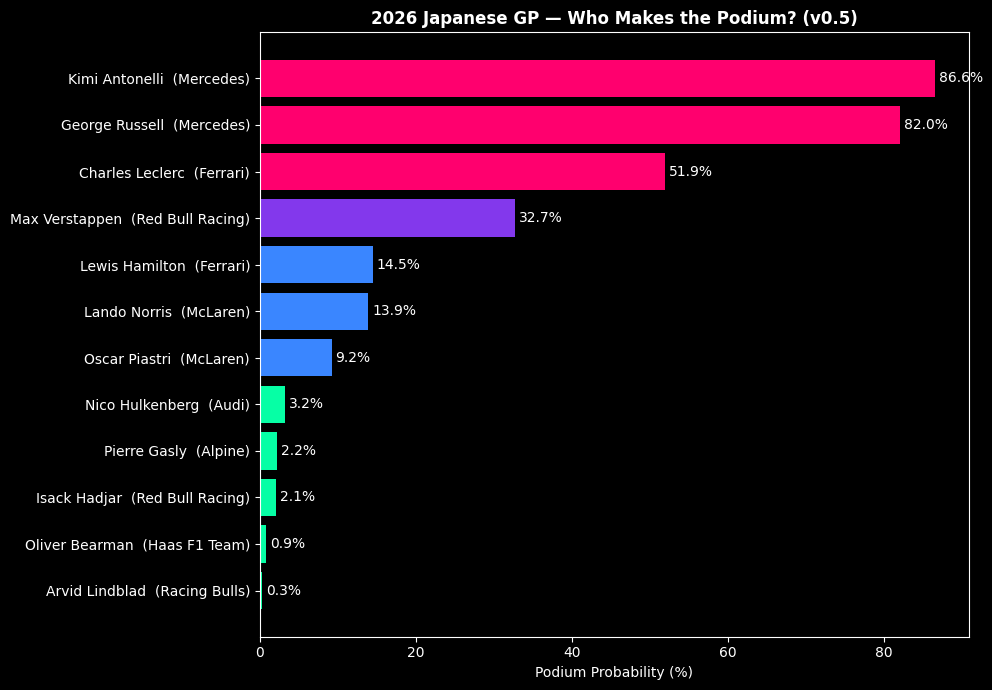

In [9]:
n_sims = 10000
position_totals = defaultdict(list)
podium_counts = defaultdict(int)
win_counts = defaultdict(int)
top5_counts = defaultdict(int)
top10_counts = defaultdict(int)

for _ in range(n_sims):
    sim = [(p['Driver'], p['Predicted'] + np.random.normal(0, residual_std)) for p in japan_preds]
    sim.sort(key=lambda x: x[1])
    for pos, (d, _) in enumerate(sim):
        position_totals[d].append(pos+1)
        if pos == 0: win_counts[d] += 1
        if pos < 3: podium_counts[d] += 1
        if pos < 5: top5_counts[d] += 1
        if pos < 10: top10_counts[d] += 1

prob_data = [{'Driver': p['Driver'], 'Team': p['Team'], 'Rank': p['Rank'],
    'Win': win_counts[p['Driver']]/n_sims*100, 'Podium': podium_counts[p['Driver']]/n_sims*100,
    'Top5': top5_counts[p['Driver']]/n_sims*100, 'Top10': top10_counts[p['Driver']]/n_sims*100}
    for p in japan_preds]
prob_df = pd.DataFrame(prob_data).sort_values('Win', ascending=False)

print("=" * 80)
print("  🎲 PODIUM PROBABILITIES (10,000 Simulated Races)")
print("=" * 80)
print(f"\n  {'Driver':22s}  {'Team':18s}  {'Win':>6s}  {'Podium':>7s}  {'Top 5':>6s}  {'Top 10':>7s}")
print("  " + "-" * 72)
for _, r in prob_df.head(15).iterrows():
    bar = '█' * int(r['Win']/2)
    print(f"  {r['Driver']:22s}  {r['Team']:18s}  {r['Win']:>5.1f}%  {r['Podium']:>6.1f}%  {r['Top5']:>5.1f}%  {r['Top10']:>6.1f}%  {bar}")

fig, ax = plt.subplots(figsize=(10, 7))
top12 = prob_df.head(12).sort_values('Podium')
colors = ['#ff006e' if p > 40 else '#8338ec' if p > 15 else '#3a86ff' if p > 5 else '#06ffa5' for p in top12['Podium']]
bars = ax.barh(top12['Driver'] + '  (' + top12['Team'] + ')', top12['Podium'], color=colors)
ax.set_xlabel('Podium Probability (%)')
ax.set_title('2026 Japanese GP — Who Makes the Podium? (v0.5)', fontweight='bold')
for bar, val in zip(bars, top12['Podium']):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../data/podium_v5.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Teammate Battles


In [10]:
teams_2026 = {}
for p in japan_preds:
    t = p['Team']
    if t not in teams_2026: teams_2026[t] = []
    teams_2026[t].append(p['Driver'])
print("=" * 60)
print("  🤝 TEAMMATE HEAD-TO-HEAD")
print("=" * 60)
print()
for team, drivers in sorted(teams_2026.items()):
    if len(drivers) >= 2:
        d1, d2 = drivers[0], drivers[1]
        d1w = sum(1 for i in range(n_sims) if position_totals[d1][i] < position_totals[d2][i])
        d1p, d2p = d1w/n_sims*100, 100-d1w/n_sims*100
        b = int(d1p/100*40)
        print(f"  {team}")
        print(f"  {d1:20s} {'█'*b}{'░'*(40-b)} {d2:>20s}")
        print(f"  {d1p:>19.1f}% {'':40s} {d2p:<.1f}%")
        print()


  🤝 TEAMMATE HEAD-TO-HEAD

  Alpine
  Pierre Gasly         ███████████████████████████████░░░░░░░░░     Franco Colapinto
                 77.5%                                          22.5%

  Aston Martin
  Fernando Alonso      ██████████████████████░░░░░░░░░░░░░░░░░░         Lance Stroll
                 55.9%                                          44.1%

  Audi
  Nico Hulkenberg      ████████████████████████████████████░░░░    Gabriel Bortoleto
                 90.7%                                          9.3%

  Cadillac
  Sergio Perez         ███████████████████████░░░░░░░░░░░░░░░░░      Valtteri Bottas
                 59.1%                                          40.9%

  Ferrari
  Charles Leclerc      ██████████████████████████████░░░░░░░░░░       Lewis Hamilton
                 76.7%                                          23.3%

  Haas F1 Team
  Oliver Bearman       █████████████████████████████░░░░░░░░░░░         Esteban Ocon
                 74.5%                    

## 10. F1 Fantasy Picks


In [11]:
race_pts = {1:25,2:18,3:15,4:12,5:10,6:8,7:6,8:4,9:2,10:1}
quali_pts = {1:10,2:9,3:8,4:7,5:6,6:5,7:4,8:3,9:2,10:1}
price_estimate = {'Mercedes':28,'Ferrari':25,'McLaren':22,'Red Bull Racing':20,
    'Aston Martin':12,'Alpine':10,'Racing Bulls':9,'Haas F1 Team':8,'Williams':8,'Audi':7,'Cadillac':6}

fantasy = []
for p in japan_preds:
    d = p['Driver']
    exp_race = np.mean([race_pts.get(pos, 0) for pos in position_totals[d]])
    eq = max(1, min(22, int(p['Predicted']*0.9)))
    exp_q = quali_pts.get(eq, 0)
    avg_sim = np.mean(position_totals[d])
    gained = max(0, eq - avg_sim)
    total = exp_race + exp_q + gained * 1.5
    price = price_estimate.get(p['Team'], 10)
    fantasy.append({'Driver': d, 'Team': p['Team'], 'Rank': p['Rank'],
        'Race_Pts': exp_race, 'Quali_Pts': exp_q, 'Bonus': gained*1.5,
        'Total': total, 'Price': price, 'Value': total/price if price > 0 else 0})

fantasy_df = pd.DataFrame(fantasy).sort_values('Total', ascending=False)

print("=" * 85)
print("  🏆 F1 FANTASY PICKS — Japan GP (v0.5)")
print("=" * 85)
print(f"\n  {'Driver':22s}  {'Team':16s}  {'Pred':>4s}  {'Race':>5s}  {'Qual':>5s}  {'Bonus':>5s}  {'TOTAL':>6s}  {'~$M':>4s}  {'Value':>5s}")
print("  " + "-" * 82)
for _, r in fantasy_df.iterrows():
    star = '⭐' if r['Value'] > 1.2 else '  '
    print(f"  {r['Driver']:22s}  {r['Team']:16s}  P{r['Rank']:>2.0f}  {r['Race_Pts']:>5.1f}  {r['Quali_Pts']:>5.0f}  {r['Bonus']:>5.1f}  {r['Total']:>5.1f}  ${r['Price']:>3.0f}  {r['Value']:>4.2f}  {star}")

print("\n  💡 RECOMMENDED:")
vp = fantasy_df.sort_values('Value', ascending=False)
print("  🔥 Best value:")
for _, r in vp.head(5).iterrows():
    print(f"     → {r['Driver']:22s} ({r['Team']}) — {r['Total']:.1f} pts / ${r['Price']}M = {r['Value']:.2f}")
b = fantasy_df.iloc[0]
print(f"\n  🚀 2x Boost: {b['Driver']} — {b['Total']:.1f} × 2 = {b['Total']*2:.1f}")
print("\n  🏗️ Constructors:")
cf = fantasy_df.groupby('Team').agg(c=('Total','sum'),p=('Price','first')).sort_values('c',ascending=False)
for t, r in cf.head(3).iterrows():
    print(f"     → {t:22s} — {r['c']:.1f} combined pts")


  🏆 F1 FANTASY PICKS — Japan GP (v0.5)

  Driver                  Team              Pred   Race   Qual  Bonus   TOTAL   ~$M  Value
  ----------------------------------------------------------------------------------
  Kimi Antonelli          Mercedes          P 1   19.6     10    0.0   29.6  $ 28  1.06    
  George Russell          Mercedes          P 2   18.5      9    0.0   27.5  $ 28  0.98    
  Charles Leclerc         Ferrari           P 3   13.8      7    0.3   21.1  $ 25  0.84    
  Max Verstappen          Red Bull Racing   P 4   11.1      6    0.2   17.3  $ 20  0.86    
  Lewis Hamilton          Ferrari           P 6    7.9      5    0.0   12.9  $ 25  0.52    
  Lando Norris            McLaren           P 5    7.8      5    0.0   12.8  $ 22  0.58    
  Oscar Piastri           McLaren           P 7    6.4      4    0.0   10.4  $ 22  0.47    
  Nico Hulkenberg         Audi              P 8    3.8      3    0.0    6.8  $  7  0.97    
  Pierre Gasly            Alpine            P 9 

## 11. My Fantasy Teams


In [12]:
team1 = {
    'name': "Russellin' for Position",
    'drivers': [
        {'name': 'George Russell', 'price': 28.0, 'boost': True},
        {'name': 'Charles Leclerc', 'price': 23.4, 'boost': False},
        {'name': 'Kimi Antonelli', 'price': 23.8, 'boost': False},
        {'name': 'Oliver Bearman', 'price': 8.6, 'boost': False},
        {'name': 'Gabriel Bortoleto', 'price': 6.4, 'boost': False},
    ],
    'constructors': [{'name': 'Audi', 'price': 5.4}, {'name': 'Cadillac', 'price': 5.2}],
    'free_transfers': 3, 'cost_cap_remaining': 0.2
}
team2 = {
    'name': "Leclerc Me if You Can",
    'drivers': [
        {'name': 'Max Verstappen', 'price': 28.1, 'boost': True},
        {'name': 'Charles Leclerc', 'price': 23.4, 'boost': False},
        {'name': 'Kimi Antonelli', 'price': 23.8, 'boost': False},
        {'name': 'Franco Colapinto', 'price': 7.0, 'boost': False},
        {'name': 'Gabriel Bortoleto', 'price': 6.4, 'boost': False},
    ],
    'constructors': [{'name': 'Audi', 'price': 5.4}, {'name': 'Cadillac', 'price': 5.2}],
    'free_transfers': 3, 'cost_cap_remaining': 0.3
}

def analyze(team):
    print("=" * 75)
    print(f"  📋 {team['name'].upper()}")
    print(f"  Transfers: {team['free_transfers']} | Cap: ${team['cost_cap_remaining']}M")
    print("=" * 75)
    total = 0; scores = []
    print(f"\n  {'Driver':22s}  {'$':>5s}  {'Bst':>5s}  {'Pred':>5s}  {'Pts':>6s}  {'2x Pts':>7s}  {'Val':>5s}")
    print("  " + "-" * 60)
    for d in team['drivers']:
        r = fantasy_df[fantasy_df['Driver'] == d['name']]
        if len(r) > 0:
            r = r.iloc[0]; pts = r['Total']; rank = int(r['Rank']); val = r['Value']
        else:
            pts = 0; rank = 22; val = 0
        boosted = pts*2 if d['boost'] else pts
        total += boosted
        scores.append({'name':d['name'],'price':d['price'],'pts':pts,'boosted':boosted,'value':val,'rank':rank,'boost':d['boost']})
        bs = "2x⚡" if d['boost'] else ""
        print(f"  {d['name']:22s}  ${d['price']:>4.1f}  {bs:>5s}  P{rank:>3d}  {pts:>5.1f}  {boosted:>6.1f}  {val:>4.2f}")
    
    ct = 0
    for c in team['constructors']:
        cp = fantasy_df[fantasy_df['Team'] == c['name']]['Total'].sum()
        ct += cp
    print(f"\n  📊 PROJECTED: {total+ct:.1f} pts (Drivers: {total:.1f} + Constructors: {ct:.1f})")
    
    # Transfers
    cap = team['cost_cap_remaining']
    weak = sorted(scores, key=lambda x: x['value'])
    available = fantasy_df[~fantasy_df['Driver'].isin([d['name'] for d in team['drivers']])].copy()
    print(f"\n  🔄 TRANSFERS:")
    moves = 0
    for w in weak:
        if moves >= team['free_transfers']: break
        budget = w['price'] + cap
        up = available[available['Price'] <= budget].sort_values('Total', ascending=False)
        if len(up) > 0:
            best = up.iloc[0]
            gain = best['Total'] - w['pts']
            if gain > 1:
                cd = best['Price'] - w['price']; cap -= cd; moves += 1
                em = '🟢' if gain > 5 else '🟡'
                print(f"  {em} {w['name']} → {best['Driver']} ({best['Team']})")
                print(f"     +{gain:.1f} pts | Cost: {'+' if cd>0 else ''}{cd:.1f}M | Cap: ${cap:.1f}M")
                available = available[available['Driver'] != best['Driver']]
    
    best_scorer = max(scores, key=lambda x: x['pts'])
    boost_driver = [s for s in scores if s['boost']][0]
    if best_scorer['name'] != boost_driver['name']:
        g = best_scorer['pts'] - boost_driver['pts']
        print(f"\n  ⚡ MOVE BOOST: {boost_driver['name']} → {best_scorer['name']} (+{g:.1f} pts)")
    else:
        print(f"\n  ✅ Boost correct on {boost_driver['name']}")

print()
analyze(team1)
print()
analyze(team2)



  📋 RUSSELLIN' FOR POSITION
  Transfers: 3 | Cap: $0.2M

  Driver                      $    Bst   Pred     Pts   2x Pts    Val
  ------------------------------------------------------------
  George Russell          $28.0    2x⚡  P  2   27.5    55.0  0.98
  Charles Leclerc         $23.4         P  3   21.1    21.1  0.84
  Kimi Antonelli          $23.8         P  1   29.6    29.6  1.06
  Oliver Bearman          $ 8.6         P 11    4.0     4.0  0.50
  Gabriel Bortoleto       $ 6.4         P 18    0.2     0.2  0.03

  📊 PROJECTED: 117.0 pts (Drivers: 109.8 + Constructors: 7.1)

  🔄 TRANSFERS:
  🟡 Oliver Bearman → Nico Hulkenberg (Audi)
     +2.8 pts | Cost: -1.6M | Cap: $1.8M

  ⚡ MOVE BOOST: George Russell → Kimi Antonelli (+2.0 pts)

  📋 LECLERC ME IF YOU CAN
  Transfers: 3 | Cap: $0.3M

  Driver                      $    Bst   Pred     Pts   2x Pts    Val
  ------------------------------------------------------------
  Max Verstappen          $28.1    2x⚡  P  4   17.3    34.6  0.86


## 12. Summary & Confidence

### Confidence: MEDIUM (improving)

| Version | Approach | Features | Confidence |
|---------|----------|----------|------------|
| v0.1 | ELO | 3 features | LOW |
| v0.2 | Composite | 9 features, reg-aware | LOW-MEDIUM |
| v0.3 | XGBoost | 9 features, rolling | MEDIUM |
| v0.4 | Two-model + weather | 15 features, rain scenarios | MEDIUM |
| **v0.5** | **+ speed traps + consistency** | **15 features + telemetry** | **MEDIUM** |

### What Gets Us to HIGH
- [ ] Qualifying data (Saturday) — the #1 predictor
- [ ] Practice session pace (Friday) — Suzuka-specific
- [ ] More 2026 races — each one sharpens the model significantly
- [ ] Tire degradation modeling — race strategy prediction
- [ ] Actual driver prices from F1 Fantasy app for precise value calculations
